<a href="https://colab.research.google.com/github/ZeshanRasul/RL_Experiments/blob/main/Q_Value_vs_Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
transition_probabilities = [
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0],  None,             [0.0, 0.0, 1.0]],
    [None,           [0.8, 0.1, 0.1], None]
]

In [29]:
rewards = [
    [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]
]

In [30]:
possible_actions = [[0, 1, 2], [0, 2], [1]]

In [31]:
Q_values = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
  Q_values[state, actions] = 0.0 # 0.0 for all possible actions

In [32]:
gamma = 0.90

for iteration in range(50):
  Q_prev = Q_values.copy()
  for s in range(3):
    for a in possible_actions[s]:
      Q_values[s, a] = np.sum([
          transition_probabilities[s][a][sp] *
           (rewards[s][a][sp] + gamma * Q_prev[sp].max()) for sp in range(3)
      ])

In [33]:
def step(state, action):
  probas = transition_probabilities[state][action]
  next_state = np.random.choice([0, 1, 2], p=probas)
  reward = rewards[state][action][next_state]
  return next_state, reward

In [34]:
def exploration_policy(state):
  return np.random.choice(possible_actions[state])

In [37]:
alpha0 = 0.05
decay = 0.005
gamma = 0.90
state = 0 #initial state

In [41]:
for iteration in range (10_000):
  action = exploration_policy(state)
  next_state, reward = step(state, action)
  next_value = Q_values[next_state].max() # greedy policy at the next step
  alpha = alpha0 / (1 + iteration * decay)
  Q_values[state, action] *= 1 - alpha
  Q_values[state, action] += alpha * (reward + gamma * next_value)
  state = next_state

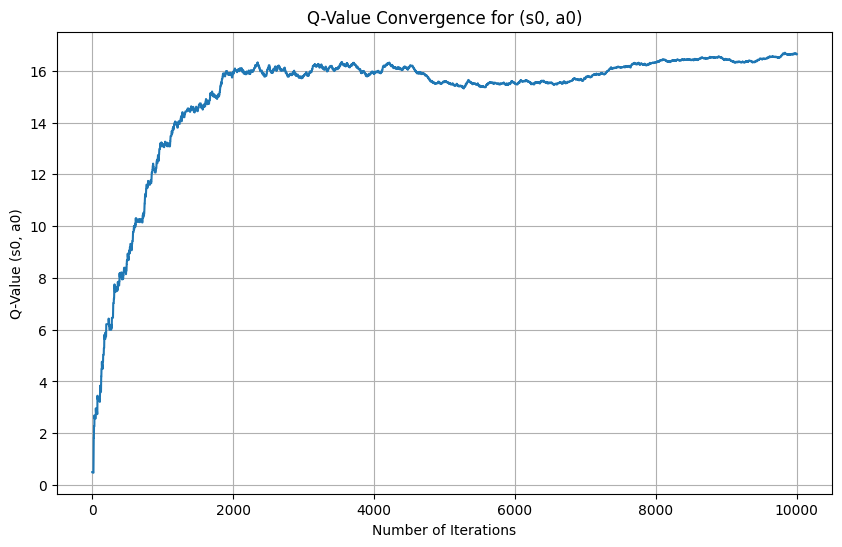

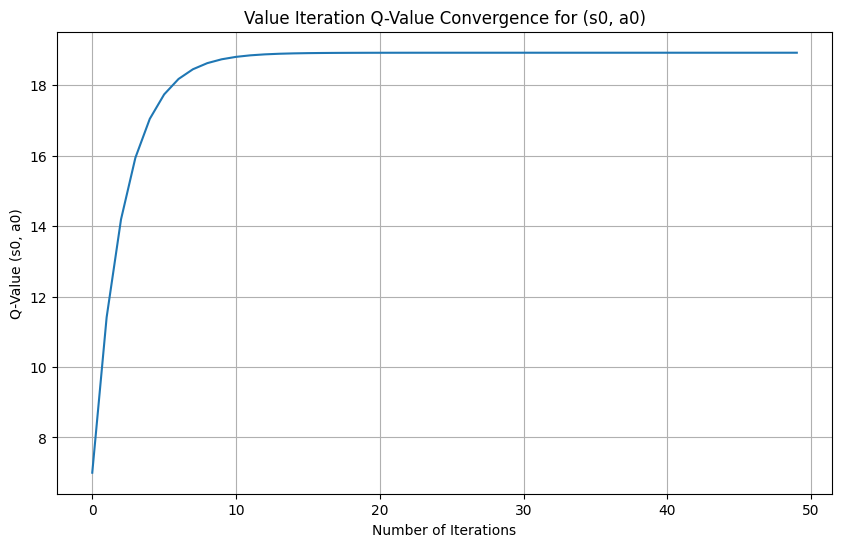

In [44]:
q_values_s0a0_history = []

# Re-initialize Q_values for this run to observe convergence from scratch
Q_values_convergence = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state_init, actions_init in enumerate(possible_actions):
  Q_values_convergence[state_init, actions_init] = 0.0 # 0.0 for all possible actions

gamma_plot = 0.90
alpha0_plot = 0.05
decay_plot = 0.005
state_plot = 0 #initial state for this simulation

for iteration in range (10_000):
  action_plot = exploration_policy(state_plot)
  next_state_plot, reward_plot = step(state_plot, action_plot)

  # Check if next_state_plot has possible actions before calling max()
  if len(possible_actions[next_state_plot]) > 0:
    next_value_plot = Q_values_convergence[next_state_plot].max() # greedy policy at the next step
  else:
    next_value_plot = 0.0 # No actions possible, so no future value from this state

  alpha_plot = alpha0_plot / (1 + iteration * decay_plot)
  Q_values_convergence[state_plot, action_plot] *= 1 - alpha_plot
  Q_values_convergence[state_plot, action_plot] += alpha_plot * (reward_plot + gamma_plot * next_value_plot)

  # Record Q_values[0,0] after each update
  q_values_s0a0_history.append(Q_values_convergence[0, 0])

  state_plot = next_state_plot

# Plotting the convergence
plt.figure(figsize=(10, 6))
plt.plot(q_values_s0a0_history)
plt.title('Q-Value Convergence for (s0, a0)')
plt.xlabel('Number of Iterations')
plt.ylabel('Q-Value (s0, a0)')
plt.grid(True)
plt.show()

value_iteration_q_s0a0_history = []

# Re-initialize Q_values for Value Iteration
Q_values_vi = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state_init_vi, actions_init_vi in enumerate(possible_actions):
  Q_values_vi[state_init_vi, actions_init_vi] = 0.0 # 0.0 for all possible actions

# Gamma from original Value Iteration cell
gamma_vi = 0.90

for iteration_vi in range(50):
  Q_prev_vi = Q_values_vi.copy()
  for s_vi in range(3):
    for a_vi in possible_actions[s_vi]:
      Q_values_vi[s_vi, a_vi] = np.sum([
          transition_probabilities[s_vi][a_vi][sp_vi] *
           (rewards[s_vi][a_vi][sp_vi] + gamma_vi * Q_prev_vi[sp_vi].max()) for sp_vi in range(3)
      ])
  # Record Q_values_vi[0,0] after each iteration
  value_iteration_q_s0a0_history.append(Q_values_vi[0, 0])

# Plotting the convergence
plt.figure(figsize=(10, 6))
plt.plot(value_iteration_q_s0a0_history)
plt.title('Value Iteration Q-Value Convergence for (s0, a0)')
plt.xlabel('Number of Iterations')
plt.ylabel('Q-Value (s0, a0)')
plt.grid(True)
plt.show()

Clearly Q-Value Iteration converges much faster than Q-Learning in the previous example when the Q-Learning algorithm is using a purely random policy. To truly leverage the power of Q-Learning, the agent should use an $\epsilon$-greedy policy where the agent at each step acts randomly with probability $\epsilon$ and greedily with probability 1-$\epsilon$.